# Salt Lake City Complete Trip Data:
## Public Sample Quick-Start Notebook

This notebook demonstrates the structure and basic use of the privacy-aware public sample of the Salt Lake City Complete Trip Data. The public sample represents one undisclosed day in 2020. It is intended for research evaluation, education, and reproducibility support. Access to the full dataset requires a separate application and may be subject to a Data Use Agreement.

### Notebook purpose

Use this notebook with the extracted public sample only. It discovers files through relative paths, avoids printing raw identifiers, and produces compact aggregate outputs. Browser execution may use a smaller tutorial subset; use a local Python environment for the complete public sample.

### Learning objectives

- Load the public release using relative paths
- Inspect trip-level and segment-level tables
- Review table dimensions and variable types
- Conduct basic missing-value and duplication checks
- Summarize travel modes using the documented statistical definition
- Link segment records to complete trips
- Inspect one selected complete trip
- Visualize a trajectory when spatial fields are available
- Export a small aggregate result

## 1. Dataset and privacy note

The release contains segment-level records that can be ordered within a reconstructed journey using `linked_trip_id` and `segment_order`. Exact calendar dates are not released. Origins and destinations are generalized spatial cells, and public identifiers are pseudonymous.

> **Methodological distinction:** Primary-mode shares should sum to approximately 100%, subject to missing or unclassified records. Percentages of trips containing each mode may exceed 100% because one complete trip can include multiple modes.

The dictionary verifies `travel_mode` as a **segment-level** mode field; it does not identify a released primary-mode field. Accordingly, this notebook reports segment counts and percentages of linked trips containing each mode. It does not label either result as “mode share.”

## 2. Environment setup

Required packages: `pandas`, `numpy`, `matplotlib`, and a Parquet engine such as `pyarrow`. Python's `pathlib` is used for portable relative paths. PySpark is not required.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python: 3.14.5
pandas: 3.0.5
numpy: 2.5.1


## 3. Locate and load files

Run the notebook from the extracted release directory. The code below checks the current directory and one expected nested release directory. If no supported table is present, later cells skip analysis cleanly and explain what is missing.

In [2]:
sample_name = "complete_trip_saltlake_2020_1day_Sample_v1.0"
candidate_roots = [Path.cwd(), Path.cwd() / sample_name]
sample_root = next(
    (root for root in candidate_roots if (root / "data").is_dir()),
    None,
)

data_dir = sample_root / "data" if sample_root else None
csv_files = sorted(data_dir.glob("*.csv")) if data_dir else []
parquet_files = sorted(data_dir.glob("*.parquet")) if data_dir else []
data_dictionary_path = sample_root / "data_dictionary.csv" if sample_root else None

print("Sample root:", sample_root if sample_root else "Not found")
print("CSV files:", [p.name for p in csv_files])
print("Parquet files:", [p.name for p in parquet_files])

def load_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    raise ValueError(f"Unsupported file type: {path.suffix}")

table_files = parquet_files or csv_files
df = None
if not table_files:
    print("No sample table found. Download and extract the public release, then rerun this notebook.")
else:
    try:
        df = load_table(table_files[0])
        print(f"Loaded {table_files[0].name}: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
    except ImportError as exc:
        print("The Parquet engine is missing. Install pyarrow and rerun the notebook.")
        print(type(exc).__name__)
    except Exception as exc:
        print(f"Could not load the sample table: {type(exc).__name__}: {exc}")

Sample root: C:\GitHub\Complete-Trip-Data-Explorer\.codex-network-validation\complete_trip_saltlake_2020_1day_Sample_v1.0
CSV files: []
Parquet files: ['part-001-of-001.parquet']
Loaded part-001-of-001.parquet: 103,774 rows × 23 columns


## 4. Inspect table schemas

The preview is deliberately small. Use the supplied data dictionary for field definitions, units, allowed values, and privacy notes.

In [3]:
if df is None:
    print("Schema inspection skipped because no table is loaded.")
else:
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    schema_preview = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
    })
    display(schema_preview)
    display(df.head(3).drop(columns=["linked_trip_id", "trip_id"], errors="ignore"))

Shape: (103774, 23)
Columns: ['linked_trip_id', 'trip_id', 'segment_order', 'travel_mode', 'year_start', 'month_start', 'day_of_week_start', '30_interv_start', 'year_end', 'month_end', 'day_of_week_end', '30_interv_end', 'geohash6_orig', 'geohash6_dest', 'trip_duration', 'network_distance', 'route_taken', 'route_speed', 'access_stop', 'access_stop_id', 'egress_stop', 'egress_stop_id', 'trip_weight']


,dtype,non_null
linked_trip_id,str,103774
trip_id,str,103774
segment_order,int64,103774
travel_mode,str,103774
year_start,int32,103774
month_start,int32,103774
day_of_week_start,int32,103774
30_interv_start,int32,103774
year_end,int32,103774
month_end,int32,103774


,segment_order,travel_mode,year_start,month_start,day_of_week_start,30_interv_start,year_end,month_end,day_of_week_end,30_interv_end,...,geohash6_dest,trip_duration,network_distance,route_taken,route_speed,access_stop,access_stop_id,egress_stop,egress_stop_id,trip_weight
0,1,car,2020,1,2,31,2020,1,2,32,...,9x23eg,20.03,3.31,"83019963, 83064659, 83023138, 83023136, 830043...","18.64, 18.64, 9.69, 9.69, 9.69, 9.69, 9.69, 9....",,,,,9.06
1,1,car,2020,1,2,33,2020,1,2,33,...,9x0qzv,8.80,3.38,"7079232820, 9553613638, 83588661, 9553613639, ...","37.28, 37.28, 7.09, 7.09, 7.09, 7.09, 31.07, 3...",,,,,21.17
2,1,car,2020,1,2,34,2020,1,2,35,...,9x22w2,12.25,5.96,"83026754, 10056512675, 83026754, 7724794941, 8...","18.64, 18.64, 34.23, 34.23, 31.07, 34.23, 34.2...",,,,,15.57


## 5. Basic quality checks

These checks summarize missing values and identifier duplication without displaying identifier values.

In [4]:
if df is None:
    print("Quality checks skipped because no table is loaded.")
else:
    missing_summary = (
        df.isna().sum().sort_values(ascending=False).rename("missing_values").to_frame()
    )
    missing_summary["missing_percent"] = (
        100 * missing_summary["missing_values"] / len(df)
    ).round(2)
    display(missing_summary.head(20))

    duplicate_summary = {}
    for column in ["trip_id", "linked_trip_id"]:
        if column in df.columns:
            duplicate_summary[column] = int(df[column].duplicated().sum())
    display(pd.Series(duplicate_summary, name="duplicate_rows_after_first"))

,missing_values,missing_percent
linked_trip_id,0,0.0
trip_id,0,0.0
segment_order,0,0.0
travel_mode,0,0.0
year_start,0,0.0
month_start,0,0.0
day_of_week_start,0,0.0
30_interv_start,0,0.0
year_end,0,0.0
month_end,0,0.0


trip_id              0
linked_trip_id    1285
Name: duplicate_rows_after_first, dtype: int64

## 6. Trip-level summary

Here, a complete linked journey is defined by `linked_trip_id`. The output contains only aggregate descriptions; it does not print identifier values.

In [5]:
journey_summary = None
required = {"linked_trip_id", "segment_order", "travel_mode"}
if df is None or not required.issubset(df.columns):
    print("Trip-level summary skipped; a loaded table with linked journey fields is required.")
else:
    journey_summary = (
        df.groupby("linked_trip_id", sort=False)
        .agg(
            segment_count=("segment_order", "size"),
            distinct_modes=("travel_mode", "nunique"),
            total_duration_minutes=("trip_duration", "sum"),
            total_network_miles=("network_distance", "sum"),
        )
    )
    print(f"Linked journeys: {len(journey_summary):,}")
    display(journey_summary.describe().round(2))

Linked journeys: 102,489


,segment_count,distinct_modes,total_duration_minutes,total_network_miles
count,102489.00,102489.00,102489.00,102489.00
mean,1.01,1.01,25.27,7.67
std,0.13,0.10,41.11,9.78
min,1.00,1.00,0.03,0.01
25%,1.00,1.00,9.37,1.79
50%,1.00,1.00,16.23,4.26
75%,1.00,1.00,28.07,9.67
max,6.00,4.00,1427.43,185.38


## 7. Segment-level summary

Each released row represents a reconstructed single-mode segment. Durations and network distances are summarized without expanding the data using weights.

In [6]:
if df is None:
    print("Segment-level summary skipped because no table is loaded.")
else:
    numeric_fields = [c for c in ["trip_duration", "network_distance", "segment_order"] if c in df]
    print(f"Segment records: {len(df):,}")
    if numeric_fields:
        display(df[numeric_fields].describe().round(2))

Segment records: 103,774


,trip_duration,network_distance,segment_order
count,103774.00,103774.00,103774.00
mean,24.95,7.58,1.02
std,40.70,9.60,0.15
min,0.03,0.01,1.00
25%,9.23,1.77,1.00
50%,16.10,4.20,1.00
75%,27.80,9.53,1.00
max,1427.43,182.62,6.00


## 8. Mode analysis

The first table counts segment records by their inferred `travel_mode`. The second deduplicates each `linked_trip_id`–`travel_mode` combination before calculating the percentage of linked journeys that contain each mode. Because a journey may contain multiple modes, the second table can total more than 100%.

In [7]:
mode_counts = None
if df is None or "travel_mode" not in df.columns:
    print("Mode analysis skipped; the travel_mode field is unavailable.")
else:
    mode_counts = df["travel_mode"].value_counts(dropna=False).rename("segment_records").to_frame()
    display(mode_counts)

    if "linked_trip_id" in df.columns:
        trip_modes = df[["linked_trip_id", "travel_mode"]].drop_duplicates()
        total_linked_trips = df["linked_trip_id"].nunique()
        trips_containing_mode = (
            trip_modes.groupby("travel_mode")["linked_trip_id"]
            .nunique()
            .rename("linked_trips_containing_mode")
            .to_frame()
        )
        trips_containing_mode["percent_of_linked_trips"] = (
            100 * trips_containing_mode["linked_trips_containing_mode"] / total_linked_trips
        ).round(2)
        display(trips_containing_mode.sort_values("linked_trips_containing_mode", ascending=False))

,segment_records
travel_mode,
car,81539
walk/bike,18304
bus,2502
rail,1429


,linked_trips_containing_mode,percent_of_linked_trips
travel_mode,,
car,81445,79.47
walk/bike,18288,17.84
bus,2411,2.35
rail,1313,1.28


## 9. Join trip and segment records

The current public sample stores segment fields in one table rather than separate trip and segment files. This example derives a journey-level table and joins its aggregate measures back to segment rows. The joined preview omits identifiers.

In [8]:
segments_with_journey = None
if df is None or journey_summary is None:
    print("Join example skipped because journey aggregates are unavailable.")
else:
    segments_with_journey = df.merge(
        journey_summary.reset_index(), on="linked_trip_id", how="left", validate="many_to_one"
    )
    preview_columns = [c for c in [
        "segment_order", "travel_mode", "trip_duration", "network_distance",
        "segment_count", "distinct_modes", "total_duration_minutes", "total_network_miles"
    ] if c in segments_with_journey]
    display(segments_with_journey[preview_columns].head(5))

,segment_order,travel_mode,trip_duration,network_distance,segment_count,distinct_modes,total_duration_minutes,total_network_miles
0,1,car,20.03,3.31,1,1,20.03,3.31
1,1,car,8.80,3.38,1,1,8.80,3.38
2,1,car,12.25,5.96,1,1,12.25,5.96
3,1,car,39.58,7.02,1,1,39.58,7.02
4,1,car,8.80,2.93,1,1,8.80,2.93


## 10. Select one complete trip

A fixed random seed makes the selection reproducible. The raw linked-trip and segment identifiers are intentionally excluded from the preview.

In [9]:
selected_journey = None
if df is None or "linked_trip_id" not in df.columns:
    print("Journey selection skipped because linked_trip_id is unavailable.")
else:
    eligible_ids = df["linked_trip_id"].dropna().unique()
    if len(eligible_ids) == 0:
        print("Journey selection skipped because no eligible linked journeys were found.")
    else:
        selected_id = rng.choice(eligible_ids)
        selected_journey = df.loc[df["linked_trip_id"].eq(selected_id)].sort_values("segment_order")
        safe_columns = [c for c in [
            "segment_order", "travel_mode", "trip_duration", "network_distance",
            "geohash6_orig", "geohash6_dest"
        ] if c in selected_journey]
        print(f"Selected journey contains {len(selected_journey)} segment(s).")
        display(selected_journey[safe_columns].reset_index(drop=True))

Selected journey contains 1 segment(s).


,segment_order,travel_mode,trip_duration,network_distance,geohash6_orig,geohash6_dest
0,1,car,13.08,5.09,9x0q7y,9x0qu0


## 11. Visualize a selected trajectory

The companion `network.zip` package resolves `route_taken` node identifiers to generalized network coordinates. Place `network.zip` beside the extracted release directory. The code selects the correct node table for car, walk/bike, bus, or rail; reads only the required identifier and coordinate columns; and does not display raw node or trip identifiers.

The current companion archive contains `node_auto.csv`, `node_walkbike.csv`, and `node_transit.csv` under its `network/` directory. If the archive is absent or a route cannot be resolved, this optional visualization skips cleanly without interrupting the notebook.

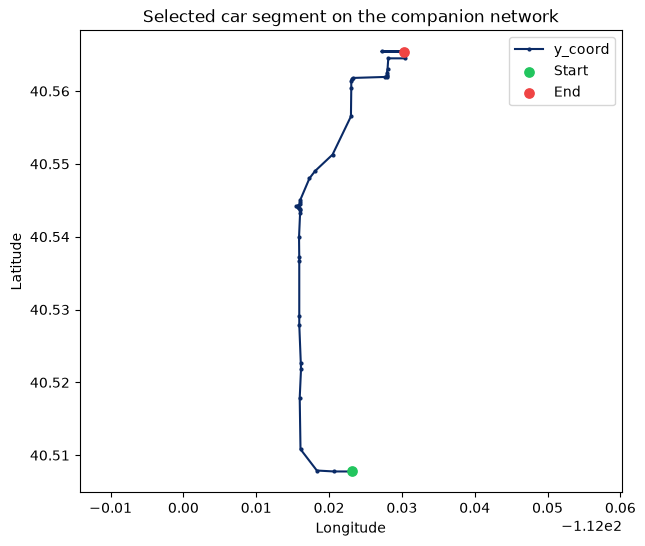

Resolved 43 of 43 route nodes.


In [10]:
import zipfile

if selected_journey is None:
    print("Trajectory preview skipped because no journey is selected.")
else:
    network_candidates = [
        Path.cwd() / "network.zip",
        (sample_root.parent / "network.zip") if sample_root else Path("__missing__"),
        Path.cwd() / "data" / "release_sample" / "network.zip",
    ]
    network_zip = next((p for p in network_candidates if p.is_file()), None)

    route_rows = selected_journey.loc[
        selected_journey["route_taken"].notna()
        & selected_journey["route_taken"].astype(str).ne("-1")
    ] if "route_taken" in selected_journey else selected_journey.iloc[0:0]

    if network_zip is None:
        print("Trajectory preview skipped. Place network.zip beside the extracted release directory.")
    elif route_rows.empty:
        print("The selected journey has no route node sequence to visualize.")
    else:
        route_row = route_rows.iloc[0]
        mode = str(route_row["travel_mode"]).lower()
        route_nodes = [node.strip() for node in str(route_row["route_taken"]).split(",") if node.strip()]

        if mode == "car":
            node_member, id_column = "network/node_auto.csv", "osm_node_id"
        elif mode == "walk/bike":
            node_member, id_column = "network/node_walkbike.csv", "osm_node_id"
        elif mode in {"bus", "rail"}:
            node_member, id_column = "network/node_transit.csv", "node_id"
        else:
            node_member = id_column = None

        if not node_member:
            print(f"No companion node table is documented for mode: {mode}")
        else:
            with zipfile.ZipFile(network_zip) as archive:
                with archive.open(node_member) as node_file:
                    nodes = pd.read_csv(
                        node_file,
                        usecols=[id_column, "x_coord", "y_coord"],
                        dtype={id_column: "string"},
                    )

            nodes[id_column] = nodes[id_column].str.strip()
            route_points = (
                nodes.drop_duplicates(id_column)
                .set_index(id_column)
                .reindex(route_nodes)[["x_coord", "y_coord"]]
                .apply(pd.to_numeric, errors="coerce")
                .dropna()
            )

            if len(route_points) < 2:
                print("Fewer than two route nodes could be resolved in the companion network.")
            else:
                ax = route_points.plot(
                    x="x_coord", y="y_coord", marker="o", markersize=2,
                    linewidth=1.5, figsize=(7, 6), legend=False, color="#0A2A66"
                )
                ax.scatter(route_points.iloc[0]["x_coord"], route_points.iloc[0]["y_coord"],
                           color="#22c55e", s=45, label="Start", zorder=3)
                ax.scatter(route_points.iloc[-1]["x_coord"], route_points.iloc[-1]["y_coord"],
                           color="#ef4444", s=45, label="End", zorder=3)
                ax.set(title=f"Selected {mode} segment on the companion network",
                       xlabel="Longitude", ylabel="Latitude")
                ax.set_aspect("equal", adjustable="datalim")
                ax.legend()
                plt.show()
                print(f"Resolved {len(route_points):,} of {len(route_nodes):,} route nodes.")

## 12. Export a small derived result

This cell exports only an aggregate mode-count table to a relative `outputs` directory. It never exports restricted records or raw identifiers.

In [11]:
if mode_counts is None:
    print("Export skipped because no aggregate mode result is available.")
else:
    output_dir = Path("outputs")
    output_dir.mkdir(exist_ok=True)
    output_path = output_dir / "segment_mode_counts.csv"
    mode_counts.to_csv(output_path)
    print("Wrote aggregate result:", output_path)

Wrote aggregate result: outputs\segment_mode_counts.csv


## 13. Citation

Li, R., Luo, W., Wu, X., & Xiong, C. (2026). *Complete Trip: A Linked Multimodal Human Mobility Dataset*. arXiv:2607.15436. https://arxiv.org/abs/2607.15436

Check the project portal for citation updates if a journal DOI becomes available.

## 14. Responsible Use

- Do not attempt to identify individuals or devices.
- Do not combine the sample with external data for re-identification.
- Do not redistribute restricted full-dataset records.
- Report results at an appropriate level of aggregation.
- Follow the dataset license and any applicable Data Use Agreement.